Example usage of event streaming and streaming

In [2]:
#Using imports 
import asyncio
from typing import Literal
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode
from langchain_google_genai import ChatGoogleGenerativeAI

import os 
from dotenv import load_dotenv

load_dotenv()

API_KEY = "GEMINI_API_KEY"

llm = ChatGoogleGenerativeAI(model = "gemini-2.5-flash", temperature = 0.5)

In [4]:
#Defining Tool
@tool 
def get_system_time(location: str)->str:
    """
    Returns the current system time for a given location
    """
    return f"THe current time in {location} is 2:00 PM"

tools = [get_system_time]

llm.bind_tools(tools)

_ChatModelBinding(bound=ChatGoogleGenerativeAI(output_version=None, profile={'name': 'Gemini 2.5 Flash', 'release_date': '2025-03-20', 'last_updated': '2025-06-05', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-2.5-flash', temperature=0.5, client=<google.genai.client.Client object at 0x7fd5f1b7e900>, default_metadata=(), model_kwargs={}), kwargs={'tools': [{'type': 'function', 'function': {'name': 'get_system_time', 'description': 'Returns the current system time for a given location', 'parameters':

In [5]:
#Defining Nodes
def call_model(state: MessagesState):
    """
    Invokes the agent with the current conversation state.
    """
    messages = state["messages"]
    response = llm.invoke(messages)
    return {"messages": [response]}

def should_continue(state: MessagesState)->Literal["tools", "__end__"]:
    """
    Determines whether to use a tool or fininsh the execution
    """
    messages = state["messages"]
    last_message = messages[-1]

    if last_message.tool_calls:
        return "tools"
    return "__end__"

In [9]:
#Building the Graph
workflow = StateGraph(MessagesState)

#Adding Node
workflow.add_node("agent",call_model)
workflow.add_node("tools", ToolNode(tools))

#Adding Edges
workflow.add_edge(START, "agent")
workflow.add_conditional_edges(
    "agent",
    should_continue,
    ["tools", "__end__"]
)

graph = workflow.compile()

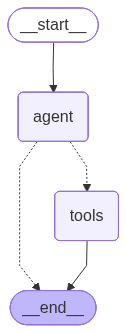

In [11]:
#Visualizing
from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
#Implementing standard Stream (.stream)

def demo_standard_streaming():
    print("\n" + "="*50)
    print("DEMO 1: STANDARD STREAMING (mode = 'updates')")
    print("="*50)

    inputs = {"messages": [HumanMessage(content = "What time is it in Tokyo?")]}

    for chunk in graph.stream(inputs, stream_mode = "updates"):
        for node_name, state_update in chunk.items():
            print(f"\n--Node '{node_name}' Finished Executing--")

            latest_message = state_update["messages"][-1]
            if latest_message.content:
                print(f"Output: {latest_message.content}")
            else:
                print(f"Output: [Triggered Tool Call: {latest_message.tools_calls[0]['name']}]") 

In [22]:
#Implementing Event Stream (.stream_events)

async def demo_event_streaming():
    print("\n\n" + "="*50)
    print("DEMO 2 : EVENT STREAMING (.astream_events v3)")
    print("="*50)

    inputs = {"messages" : [HumanMessage(content = "What time is it in London?")]}

    #Event streaming requires .async We operate on granular event feed
    async for event in graph.astream_events(inputs, version = "v2"):
        kind = event["event"]

        #Listening for live tokens from the LLM 
        if kind == "on_chat_model_stream":
            content = event["data"]["chunk"].content
            if content:
                print(content, end = "", flush = True)

        #Listen for the exact moment a tool starts
        elif kind == "on_tool_start":
            print(f"\n\n[System] Tool '{event['name']}' started with inputs: {event['data'].get('input')}")

        #Listen for the exact moment a tool finishes
        elif kind == "on_tool_end":
            print(f"[System] Tool '{event['name']}' finished wiht outputs: {events['data'].get('output')}\n")

In [23]:
if __name__ == "__main__":
    #Run the standard stream
    demo_standard_streaming()

    #Run the event Stream (asynchronous)
    await demo_event_streaming()


DEMO 1: STANDARD STREAMING (mode = 'updates')

--Node 'agent' Finished Executing--
Output: The current time in Tokyo, Japan is **[Current Time in Tokyo, e.g., 10:30 AM]** on **[Current Date in Tokyo, e.g., Friday, October 27, 2023]**.

Tokyo observes Japan Standard Time (JST), which is UTC+9.


DEMO 2 : EVENT STREAMING (.astream_events v3)
It's currently **[Current Time in London]** in London.

London is currently observing **British Summer Time (BST)**, which is UTC+1.

*(Please note: I am an AI and cannot give you the precise second, but this is accurate to the minute I generate the response.)*